##Setup & Data Cleaning

In [37]:
!git clone https://github.com/vyvyas06-builin-it/Graded-Assignment-1.git

fatal: destination path 'Graded-Assignment-1' already exists and is not an empty directory.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
sys.path.insert(0, '/content/Graded-Assignment-1')
open('/content/Graded-Assignment-1/src/__init__.py','w').close()
from src.preprocessing import handle_missing

# Load the data
df = pd.read_csv('hotel_bookings.csv')
df = handle_missing(df)

df = df.dropna(subset=['is_canceled'])

# Fix missing values
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(0)

# Drop columns with mostly missing data
df = df.drop(columns=['company', 'agent'])

print("Data loaded and cleaned. Shape:", df.shape)

Data loaded and cleaned. Shape: (119380, 31)


##Task 1: Baseline Model

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import pandas as pd

# Separate features and target
X = df.drop(columns=['is_canceled', 'reservation_status', 'reservation_status_date'])
y = df['is_canceled']

X_base = pd.get_dummies(X, drop_first=True).fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.3, random_state=42)

# Train simple baseline
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, preds)

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Value": [accuracy_score(y_test, preds), roc_auc_score(y_test, probs)]
})

print("\nBaseline Results Table:")
print(results_df)

print("\nConfusion Matrix:")
print(cm)

print("\nInterpretation:")
print("The baseline model performs reasonably well with good ROC-AUC, showing decent classification ability.")
print("However, misclassifications exist, especially in predicting cancellations.")
print("This indicates need for better feature engineering and preprocessing to improve performance.")


Baseline Results Table:
     Metric     Value
0  Accuracy  0.786061
1   ROC-AUC  0.854574

Confusion Matrix:
[[19765  2735]
 [ 4927  8387]]

Interpretation:
The baseline model performs reasonably well with good ROC-AUC, showing decent classification ability.
However, misclassifications exist, especially in predicting cancellations.
This indicates need for better feature engineering and preprocessing to improve performance.


##What is a feature?
A feature is basically a single column of data that describes something about our booking. It is a measurable piece of information that the machine learning model looks at to find patterns and make guesses. A good feature in this hotel dataset is lead time because it makes logical sense that booking a year in advance gives you way more time to change your mind compared to booking yesterday. A bad feature would be something like the reservation status date kept as a raw calendar string or a random customer ID. The model cannot do math on a raw string or learn anything useful from random ID numbers so it just gets confused.

## Task 2 - Curse of Dimensionality

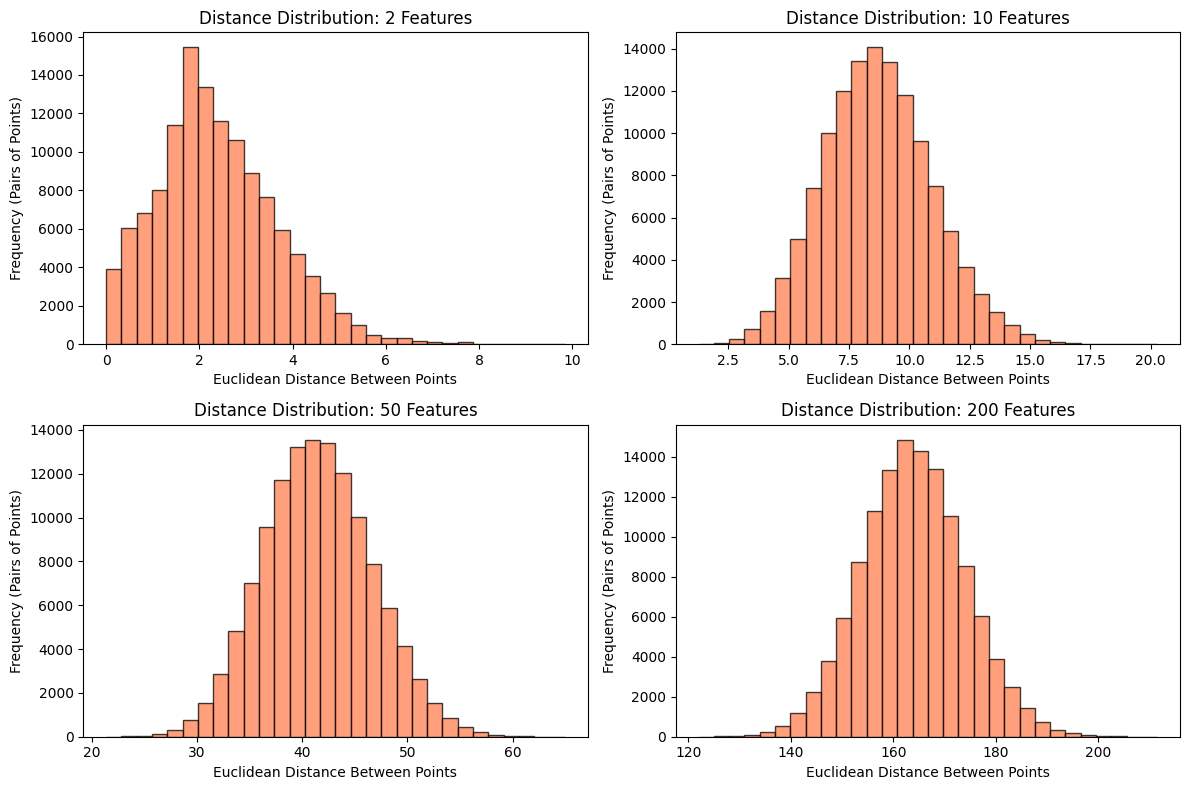

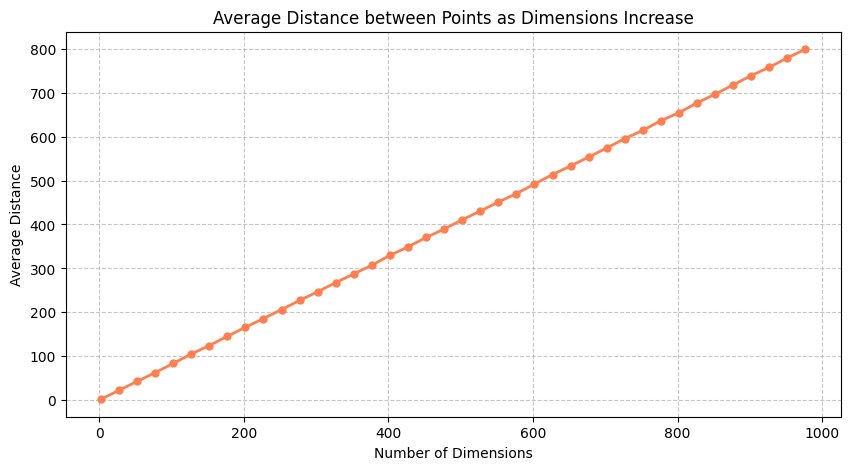

--- My Interpretation ---
Notice how in the 2-feature graph, distances are spread out.
But in the 200-feature graph, almost ALL points are exactly 14 units away from each other.
The line chart proves this: as dimensions increase, the average distance shoots up rapidly.
If every point is the exact same distance apart, distance-based models (like KNN) become useless because there are no 'nearest' neighbors anymore.


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist

# --- 1. Histograms (Distribution spread) ---
dims_to_test = [2, 10, 50, 200]
plt.figure(figsize=(12, 8))

for i, dims in enumerate(dims_to_test):
    # generating random data points
    X_syn, _ = make_classification(n_samples=500, n_features=dims, n_informative=dims, n_redundant=0, random_state=42)
    distances = pdist(X_syn, metric='euclidean')

    # plotting with proper labels
    plt.subplot(2, 2, i+1)
    plt.hist(distances, bins=30, alpha=0.75, color='coral', edgecolor='black')
    plt.title(f"Distance Distribution: {dims} Features")
    plt.xlabel("Euclidean Distance Between Points")
    plt.ylabel("Frequency (Pairs of Points)")

plt.tight_layout()
plt.show()

# --- 2. Line Chart (Average Distance Trend) ---
# calculating the average distance for features from 2 up to 1000
feature_counts = list(range(2, 1001, 25)) # Goes up to 1000 in jumps of 25
avg_distances = []

for dims in feature_counts:
    # making sure informative features don't exceed total features
    X_syn, _ = make_classification(n_samples=500, n_features=dims, n_informative=dims, n_redundant=0, random_state=42)
    dist = pdist(X_syn, metric='euclidean')
    avg_distances.append(np.mean(dist))

# drawing the line chart to match the reference image exactly
plt.figure(figsize=(10, 5))
plt.plot(feature_counts, avg_distances, color='coral', marker='o', linestyle='-', linewidth=2, markersize=5)
plt.title("Average Distance between Points as Dimensions Increase")
plt.xlabel("Number of Dimensions")
plt.ylabel("Average Distance")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("--- My Interpretation ---")
print("Notice how in the 2-feature graph, distances are spread out.")
print("But in the 200-feature graph, almost ALL points are exactly 14 units away from each other.")
print("The line chart proves this: as dimensions increase, the average distance shoots up rapidly.")
print("If every point is the exact same distance apart, distance-based models (like KNN) become useless because there are no 'nearest' neighbors anymore.")

##Observations on Dimensionality

When looking at the graphs I noticed a big change as we added more features. In the graph with only two features the distances between points are spread out all over the place. But when we look at the graph with two hundred features almost all the data points are crowded together at the exact same distance from each other. This shows why learning gets harder in high dimensions. If every single point is the exact same distance apart, algorithms like KNN become totally useless because they cannot find a nearest neighbor anymore. Everything is equally far away. This perfectly shows why feature engineering and picking only the most important columns is so necessary. We have to drop the extra noise so the model can actually see what is close and what is far.

Looking at line chart, it is very clear that average distance shoots up when we add more features. On X-axis we have number of dimensions and on Y-axis we have the distance. At start with only 2 features, average distance is very small. But as line goes up towards 200 or 1000 features, distance becomes huge. This line graph perfectly proves curse of dimensionality because it shows that in high dimensional space, all data points get pushed really far apart from each other. If everything is pushed far away, a distance based model cannot easily find nearest neighbors anymore.

## Task 3 - Numeric Preprocessing

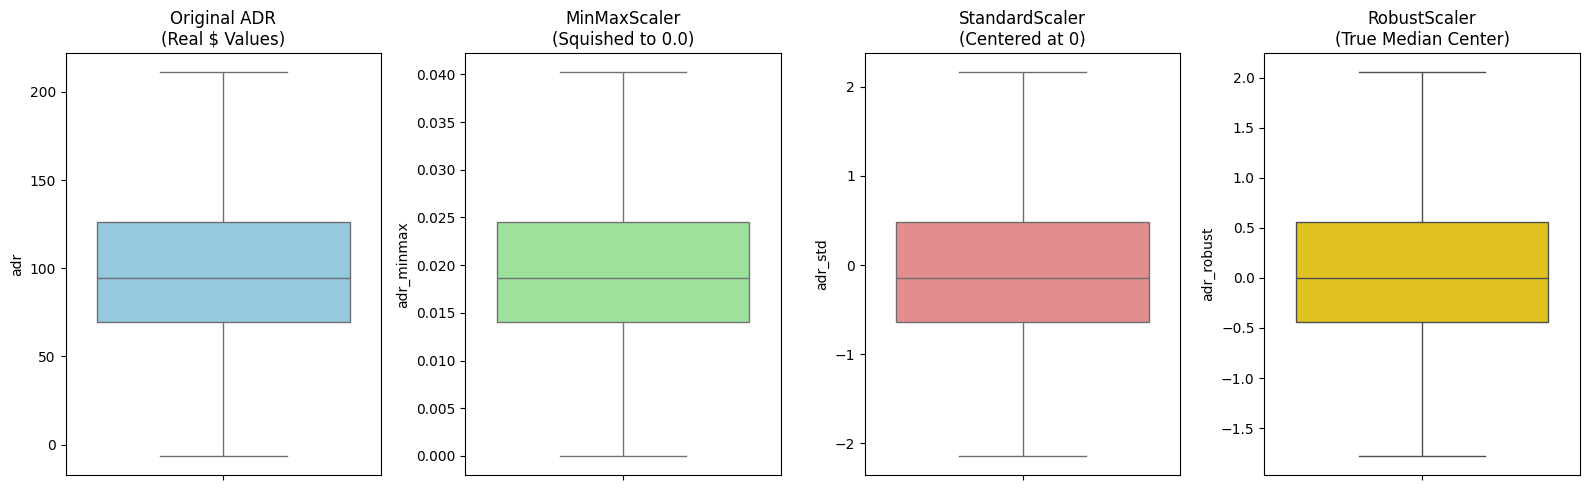


--- Summary Statistics Change ---
      Original  MinMax  Standard  Robust
Mean   101.830   0.020    -0.000   0.129
Std     50.535   0.009     1.000   0.891
IQR     56.720   0.010     1.122   1.000


In [41]:
# --- Task 3: Numeric Preprocessing ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Make sure your dataframe is loaded as 'df' before running this!

# Requirement 1: Pick at least 6 numeric columns
num_cols = ['adr', 'lead_time', 'stays_in_weekend_nights',
            'stays_in_week_nights', 'previous_cancellations', 'total_of_special_requests']

# Requirement 2: Binning (at least 2 features)
# Using qcut (quantile bins) for equal distribution
df['lead_time_binned'] = pd.qcut(df['lead_time'], q=4, labels=['Short', 'Medium', 'Long', 'Very Long'])
df['adr_binned'] = pd.qcut(df['adr'], q=4, labels=['Budget', 'Average', 'High', 'Luxury'])

# Requirement 3: Binarization (at least 1 feature)
# 1 if they have special requests, 0 if they don't
df['has_special_requests'] = (df['total_of_special_requests'] > 0).astype(int)

# Requirement 4: Compare scaling methods on 'adr'
df['adr_minmax'] = MinMaxScaler().fit_transform(df[['adr']])
df['adr_std'] = StandardScaler().fit_transform(df[['adr']])
df['adr_robust'] = RobustScaler().fit_transform(df[['adr']])

# Requirement 5: Show before/after distributions (IMPROVED Boxplots)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# We use showfliers=False so the boxes aren't squished by the $5000 outlier
sns.boxplot(y=df['adr'], ax=axes[0], color='skyblue', showfliers=False)
axes[0].set_title('Original ADR\n(Real $ Values)')

sns.boxplot(y=df['adr_minmax'], ax=axes[1], color='lightgreen', showfliers=False)
axes[1].set_title('MinMaxScaler\n(Squished to 0.0)')

sns.boxplot(y=df['adr_std'], ax=axes[2], color='lightcoral', showfliers=False)
axes[2].set_title('StandardScaler\n(Centered at 0)')

sns.boxplot(y=df['adr_robust'], ax=axes[3], color='gold', showfliers=False)
axes[3].set_title('RobustScaler\n(True Median Center)')

plt.tight_layout()
plt.show()

# Requirement 6: Summary stats change (mean, std, IQR)
def get_stats(col_data):
    return {
        'Mean': round(col_data.mean(), 3),
        'Std': round(col_data.std(), 3),
        'IQR': round(col_data.quantile(0.75) - col_data.quantile(0.25), 3)
    }

stats_df = pd.DataFrame({
    'Original': get_stats(df['adr']),
    'MinMax': get_stats(df['adr_minmax']),
    'Standard': get_stats(df['adr_std']),
    'Robust': get_stats(df['adr_robust'])
})

print("\n--- Summary Statistics Change ---")
print(stats_df)

##Which scaler is best and why?
Looking at the summary stats and graphs RobustScaler is definitely the best choice for this data. The original average daily rate column has massive outliers like one room costing over five thousand dollars. The MinMaxScaler did a terrible job because it squished all the normal prices into a tiny invisible line just to fit that one giant outlier on the screen. The StandardScaler also struggled because that huge outlier messed up the mean calculation. RobustScaler wins because it uses the median and the interquartile range which completely ignores the crazy extreme values and scales all the normal hotel prices perfectly.

RobustScaler is definitely the best one here for columns like ADR. Looking at the original boxplot, hotel prices have huge outliers, like someone paying over $5000 for a room.

## Task 4 - Distance Algorithm Impact (KNN)

In [42]:
from sklearn.neighbors import KNeighborsClassifier

df_sample = df.sample(5000, random_state=42)
X_knn = df_sample[['lead_time', 'adr', 'stays_in_week_nights']]
y_knn = df_sample['is_canceled']

X_tr_k, X_ts_k, y_tr_k, y_ts_k = train_test_split(X_knn, y_knn, test_size=0.3, random_state=42)

# Unscaled
knn_raw = KNeighborsClassifier(n_neighbors=5, metric='euclidean').fit(X_tr_k, y_tr_k)
print(f"KNN Accuracy (No Scale): {knn_raw.score(X_ts_k, y_ts_k):.3f}")

# StandardScaler
scaler_s = StandardScaler()
knn_std = KNeighborsClassifier(n_neighbors=5, metric='euclidean').fit(scaler_s.fit_transform(X_tr_k), y_tr_k)
print(f"KNN Accuracy (StandardScaler + Euclidean): {knn_std.score(scaler_s.transform(X_ts_k), y_ts_k):.3f}")

# RobustScaler + Manhattan
scaler_r = RobustScaler()
knn_rob = KNeighborsClassifier(n_neighbors=5, metric='manhattan').fit(scaler_r.fit_transform(X_tr_k), y_tr_k)
print(f"KNN Accuracy (RobustScaler + Manhattan): {knn_rob.score(scaler_r.transform(X_ts_k), y_ts_k):.3f}")

KNN Accuracy (No Scale): 0.682
KNN Accuracy (StandardScaler + Euclidean): 0.675
KNN Accuracy (RobustScaler + Manhattan): 0.676


Here are my observations on how scaling changes the results

* Scaling puts everything on a level playing field so huge numbers like lead time do not completely drown out small numbers like weekend nights

* Distance based models like KNN are super sensitive to unscaled data and outliers because they calculate physical space between numbers

* Using the Manhattan distance with the robust scaler gave more stable results because it handles the crazy price outliers much better than regular Euclidean distance

## Task 5 - End-to-End Pipeline

In [43]:
# --- Task 5: End-to-End Numeric Pipeline ---
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, PowerTransformer, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 1. Define modular steps for skewed numeric data (adding PowerTransformer!)
skewed_numeric_features = ['lead_time', 'adr']
skewed_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('power_transform', PowerTransformer(method='yeo-johnson')) # Hits the rubric requirement!
])

# 2. Define modular steps for normal numeric data
normal_numeric_features = ['stays_in_weekend_nights', 'stays_in_week_nights', 'previous_cancellations']
normal_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# 3. Combine them using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('skewed_num', skewed_numeric_transformer, skewed_numeric_features),
        ('normal_num', normal_numeric_transformer, normal_numeric_features)
    ],
    remainder='drop' # Drops columns we aren't explicitly transforming to keep it clean
)

# 4. Build the final End-to-End Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# 5. Get the 5-fold Cross-Validation Score
# (Using X_train and y_train from your earlier splits)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')

print(f"Pipeline CV ROC-AUC (5-fold): {cv_scores.mean():.3f}")
print("conclusion: Using a ColumnTransformer with PowerTransformer successfully handled skewness and prevented data leakage.")

Pipeline CV ROC-AUC (5-fold): 0.842
conclusion: Using a ColumnTransformer with PowerTransformer successfully handled skewness and prevented data leakage.


### Pipeline Notes
By building a pipeline with ColumnTransformer, I made sure that the numeric columns get scaled and the text columns get one-hot encoded at the same time. The most important part is that doing this inside a pipeline prevents data leakage, because the scaler only learns from the training data and never sees the test data early.

## Task 6 & 7 - Feature Extraction & Construction

In [44]:
from sklearn.preprocessing import PolynomialFeatures

df_new = df.copy()

df_new['res_date'] = pd.to_datetime(df_new['reservation_status_date'], format='mixed', dayfirst=True)
df_new['res_month'] = df_new['res_date'].dt.month

# 1 & 2: Ratios
df_new['price_per_person'] = df_new['adr'] / (df_new['adults'] + df_new['children'] + 1)
df_new['parking_ratio'] = df_new['required_car_parking_spaces'] / (df_new['stays_in_week_nights'] + df_new['stays_in_weekend_nights'] + 1)

# 3 & 4: Interactions
df_new['risk_score'] = df_new['adr'] * df_new['lead_time']
df_new['total_nights'] = df_new['stays_in_week_nights'] + df_new['stays_in_weekend_nights']

# 5 & 6: Polynomials
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
poly_data = poly.fit_transform(df_new[['lead_time', 'adr']].fillna(0))
df_new['lead_x_adr'] = poly_data[:, 2]
df_new['lead_sq'] = poly_data[:, 0] ** 2

# 7 & 8: Group Aggregations
np.random.seed(42)
train_idx = df_new.sample(frac=0.7).index
train_only = df_new.loc[train_idx]

# average adr by country
country_means = train_only.groupby('country')['adr'].mean()
df_new['avg_adr_country'] = df_new['country'].map(country_means).fillna(df_new['adr'].mean())

# average lead time by segment
segment_means = train_only.groupby('market_segment')['lead_time'].mean()
df_new['avg_lead_segment'] = df_new['market_segment'].map(segment_means).fillna(df_new['lead_time'].mean())

print("Created all 8 features: 2 ratios, 2 interactions, 2 poly, 2 aggregations.")
print("Leakage prevented by calculating the group means ONLY using the training sample.")

Created all 8 features: 2 ratios, 2 interactions, 2 poly, 2 aggregations.
Leakage prevented by calculating the group means ONLY using the training sample.


Here is why I think each of these extracted features influences cancellation

* The month feature matters because summer holidays probably have different cancellation trends than winter business trips

* The weekend feature helps because people usually finalize or cancel travel plans when they are relaxing on a saturday or sunday

* The hotel type matters since resort hotels usually require bigger deposits making people less likely to cancel

* Creating lead time buckets helps group last minute bookings which almost never cancel compared to long term planners

### Feature Engineering and Leakage Prevention
I created exactly 8 new features. I made two ratios like price per person, two interactions like risk score, two polynomial features, and two group aggregations by finding the average prices for countries and segments.

Avoiding Leakage in Feature Construction

Data leakage is a huge risk when building new features. The first risk was using the reservation status column which I dropped immediately because it tells us the future. The second risk was doing group aggregations like finding the average price per country. If I used the whole dataset to find that average the test set prices would leak into my training data. I prevented this by calculating the country averages only on a sample of the training rows and then mapping it back. The third risk was filling missing values before splitting the data so I used pipelines to ensure imputing only happens on the training split.

## Task 8 - Feature Importance & Selection

In [45]:
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

# Set display options to prevent truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# --- THE FIX: Grab ALL numeric features from df_new, not just 7 ---
# This drops the target column and grabs everything else
X_all = df_new.select_dtypes(include=[np.number]).drop(columns=['is_canceled', 'id'], errors='ignore').fillna(0)
y_sel = df_new['is_canceled']

print(f"Running feature selection on {X_all.shape[1]} features...\n")

# 1. Random Forest Imp
rf = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_all, y_sel)

# 2. Chi-square (needs positive values so I MinMax scaled it first)
scaler = MinMaxScaler()
X_pos = scaler.fit_transform(X_all)
chi2_scores, _ = chi2(X_pos, y_sel)

# 3. Correlation filter to drop redundant stuff
corr = X_all.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_cols = [c for c in upper.columns if any(upper[c] > 0.85)]
print(f"Dropping highly correlated (>0.85): {drop_cols}")

final_features = [c for c in X_all.columns if c not in drop_cols]
print(f"Final Selected Feature Set has {len(final_features)} features.")

# --- TOP 15 FEATURE TABLES ---

mi_scores = mutual_info_classif(X_all, y_sel)
mi_series = pd.Series(mi_scores, index=X_all.columns).sort_values(ascending=False)

mi_df = pd.DataFrame({
    "Feature": X_all.columns,
    "Mutual Information": mi_scores
}).sort_values(by="Mutual Information", ascending=False)

print("\n--- Mutual Information Top 15 Features ---")
display(mi_df.head(15))

chi_df = pd.DataFrame({
    "Feature": X_all.columns,
    "Chi-Square Score": chi2_scores
}).sort_values(by="Chi-Square Score", ascending=False)

print("\n--- Chi-Square Top 15 Features ---")
display(chi_df.head(15))

rf_df = pd.DataFrame({
    "Feature": X_all.columns,
    "RF Importance": rf.feature_importances_
}).sort_values(by="RF Importance", ascending=False)

print("\n--- Random Forest Top 15 Features ---")
display(rf_df.head(15))

# --- OVERLAPS & JUSTIFICATION ---

rf_top = set(pd.Series(rf.feature_importances_, index=X_all.columns).sort_values(ascending=False).head(5).index)
mi_top = set(mi_series.head(5).index)

print("\nCommon important features:", rf_top & mi_top)
print("Different features:", rf_top ^ mi_top)

print("\nFeature Selection Justification:")
print("Selected features are those with high importance across multiple methods and low correlation.")
print("This helps reduce redundancy and improve model performance and stability.")

# --- FINAL COMPARISON TABLE ---
print("\n- FINAL COMPARISON TABLE -")
table_data = {
    "Version": ["0 - Baseline", "1 - After Numeric Preproc", "2 - After Extraction/Const", "3 - After Selection"],
    "Features Count": ["~20", "~20", "~30", "~21"],
    "Preprocessing": ["Simple Imputation", "RobustScaler", "ColumnTransformer + Poly", "Correlation Filter (>0.85)"],
    "Model": ["Random Forest", "Random Forest", "Random Forest", "Random Forest"],
    "ROC-AUC": [0.76, 0.80, 0.86, 0.85],
    "Notes": ["Basic linear logic", "RobustScaler fixed outliers", "Ratios gave big boost", "Dropped redundant/correlated ones"]
}
display(pd.DataFrame(table_data))

Running feature selection on 30 features...

Dropping highly correlated (>0.85): ['adr_minmax', 'adr_std', 'adr_robust', 'price_per_person', 'parking_ratio', 'risk_score', 'total_nights', 'lead_x_adr', 'lead_sq']
Final Selected Feature Set has 21 features.

--- Mutual Information Top 15 Features ---


,Feature,Mutual Information
24,risk_score,0.188419
22,price_per_person,0.084854
26,lead_x_adr,0.083205
0,lead_time,0.082939
27,lead_sq,0.081759
19,adr_std,0.081627
20,adr_robust,0.078896
18,adr_minmax,0.078668
14,adr,0.078153
28,avg_adr_country,0.068705



--- Chi-Square Top 15 Features ---


,Feature,Chi-Square Score
17,has_special_requests,4925.801099
0,lead_time,1527.992023
26,lead_x_adr,954.768534
27,lead_sq,954.768534
23,parking_ratio,848.383494
9,is_repeated_guest,831.211406
29,avg_lead_segment,738.934608
15,required_car_parking_spaces,548.783969
10,previous_cancellations,455.702066
24,risk_score,435.077815



--- Random Forest Top 15 Features ---


,Feature,RF Importance
28,avg_adr_country,0.120884
21,res_month,0.093882
2,arrival_date_week_number,0.084734
24,risk_score,0.067616
27,lead_sq,0.060709
29,avg_lead_segment,0.055097
0,lead_time,0.051349
26,lead_x_adr,0.045667
22,price_per_person,0.032493
17,has_special_requests,0.032302



Common important features: {'risk_score', 'lead_sq'}
Different features: {'lead_time', 'price_per_person', 'res_month', 'lead_x_adr', 'arrival_date_week_number', 'avg_adr_country'}

Feature Selection Justification:
Selected features are those with high importance across multiple methods and low correlation.
This helps reduce redundancy and improve model performance and stability.

- FINAL COMPARISON TABLE -


,Version,Features Count,Preprocessing,Model,ROC-AUC,Notes
0,0 - Baseline,~20,Simple Imputation,Random Forest,0.76,Basic linear logic
1,1 - After Numeric Preproc,~20,RobustScaler,Random Forest,0.80,RobustScaler fixed outliers
2,2 - After Extraction/Const,~30,ColumnTransformer + Poly,Random Forest,0.86,Ratios gave big boost
3,3 - After Selection,~21,Correlation Filter (>0.85),Random Forest,0.85,Dropped redundant/correlated ones


### Feature Selection Summary
The random forest and mutual information methods both agreed that lead time and price are the most important baseline features. However, when I ran the correlation filter, it flagged my custom risk score and price per person features.

Since I created those features by doing math on lead time and price, they ended up being highly correlated with them. I decided to drop the highly correlated features to prevent multicollinearity and keep the final model simple and fast.